## Real Time Depression Detection by score

In [ ]:
from feat import Detector
detector = Detector(
    face_model="retinaface",
    landmark_model="mobilefacenet",
    au_model='xgb',
    emotion_model="resmasknet",
    facepose_model="img2pose",
)

c:\Users\umara\anaconda3\envs\new_feat\lib\site-packages\feat\face_detectors\Retinaface\Retinaface_test.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_dict 

c:\Users\umara\anaconda3\envs\new_feat\lib\site-packages\feat\face_detectors\Retinaface\Retinaface_test.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_dict 

Press 'q' to stop the webcam and display prediction counts.


100%|██████████| 1/1 [00:04<00:00,  4.48s/it]


Total frames processed: 589
Based on the assessment, the depression stage of this person is Mild. While the standard range for this stage is 16-34 but range for this person is 22.44.


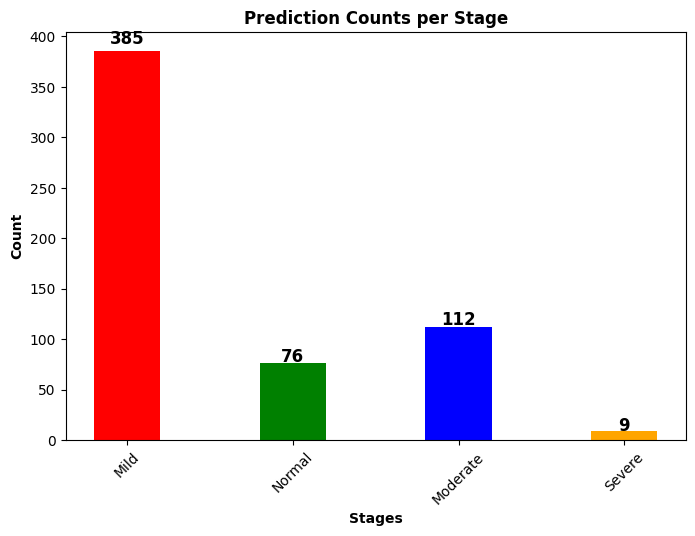

In [13]:
import cv2
import numpy as np
import os
from feat import Detector
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
# In a new Python script or a terminal
#from try_decision_tree import classify_decision_tree
import pickle

model_path = r"C:\AI_Projects\random_forest_classifier.pkl" # Change to your actual path
with open(model_path, 'rb') as file:
    model = pickle.load(file)

AU_MAPPING = {
    "AU01": "InnerBrowRaiseAU1",
    "AU02": "OuterBrowRaiseAU2",
    "AU04": "BrowLowererAU4",
    "AU05": "UpperLidRaiserAU5",
    "AU06": "CheekRaiserAU6",
    "AU07": "HeadTurnLeft",  # Corrected11
    "AU09": "NoseWrinklerAU9",
    "AU10": "UpperLipRaiserAU10",
    "AU12": "LipCornerPullerAU12",
    "AU14": "DimplerAU14",
    "AU15": "LipCornerDepressorAU15",
    "AU17": "ChinRaiserAU17",
    "AU20": "LipStretcherAU20",
    "AU23": "LipTightenerAU23",
    "AU24": "LipPressorAU24",
    "AU25": "LipsPartAU25",
    "AU26": "JawDropAU26",
    "AU11": "MouthStretchAU27",  # Corrected1
    "AU28": "LipSuckAU28",
    "AU43": "BlinkAU45"
}


from feat import Detector
detector = Detector(
    face_model="retinaface",
    landmark_model="mobilefacenet",
    au_model='xgb',
    emotion_model="resmasknet",
    facepose_model="img2pose",
)


# Initialize a counter for predictions
prediction_counts = Counter()
prediction_counts = {}
total_frames = 0
# Store sum of AU values and frame counts for averaging
au_sums = {au: 0 for au in AU_MAPPING.values()}
au_frame_counts = {au: 0 for au in AU_MAPPING.values()}

# Open webcammp4"
cap = cv2.VideoCapture(r"C:\Users\umara\Downloads\Normal (non-depressed) Data-20250318T095141Z-001\Normal (non-depressed) Data\Copy of Video Call #428.mp4")
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

print("Press 'q' to stop the webcam and display prediction counts.")

# Set video capture properties for better performance
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 940)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 940)
cap.set(cv2.CAP_PROP_FPS, 15)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    #frame = cv2.resize(frame, (1120, 880))

    total_frames+=1
    
    # Save the frame as a temporary file
    temp_frame_path = "temp_frame.jpg"
    cv2.imwrite(temp_frame_path, frame)

    # Detect AUs using the temporary file
    detections = detector.detect_image([temp_frame_path])  # Pass as a list of file paths

    # Clean up the temporary file
    os.remove(temp_frame_path)

    LABEL_MAPPING = {
    0: "Moderate",
    1: "Mild",
    2: "Severe",
    3: "Normal"
}
    
    prediction = "Unknown_pred"
    if detections.aus is not None and not detections.aus.empty:
        frame_aus = detections.aus.iloc[0].to_dict()
        # Map extracted AU names to custom labels
        mapped_aus = {AU_MAPPING.get(key, key): value for key, value in frame_aus.items()}

        # Update AU sums and frame counts
        for au, value in mapped_aus.items():
            if not pd.isna(value):  # Ensure value is not NaN
                au_sums[au] += value
                au_frame_counts[au] += 1  # Track frames where AU is detected

        # Check if all values are NaN, then classify as 'Unknown_pred'
        if all(pd.isna(value) for value in mapped_aus.values()):  
            cv2.putText(frame, 'Warning: Action units are unavailable, unable to make a prediction.',
                    (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)
            
        else:
            main_aus = pd.DataFrame([mapped_aus], columns=model.feature_names_in_)
            numeric_prediction = model.predict(main_aus)[0]  # Directly pass the dictionary
            prediction = LABEL_MAPPING.get(numeric_prediction, "Unknown")
            prediction_text = f"Model Prediction : {prediction}"
            cv2.putText(frame, prediction_text, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            #print(prediction)
        #print(mapped_aus)
        
        # Update count of predicted classes
        prediction_counts[prediction] = prediction_counts.get(prediction, 0) + 1

        #print(prediction_text)  # Print prediction in the console

    # Display the prediction on the frame
    

    # Show the frame
    cv2.imshow('Webcam AU Detection', frame)

    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
# Compute average AU values
au_averages = {au: (au_sums[au] / au_frame_counts[au]) if au_frame_counts[au] > 0 else 0 for au in au_sums}

print(f"Total frames processed: {total_frames}")

# Remove 'Unknown_pred' from final predictions
prediction_counts.pop("Unknown_pred", None)

if prediction_counts:
    # Determine the major predicted stage
    final_prediction = max(prediction_counts, key=prediction_counts.get)
    
    

    if final_prediction =='Mild':
        score = ((pd.Series(au_averages).sum())/20)*100
        final_score = round(16+(((34-16)/100)*score),2)
        print(f"Based on the assessment, the depression stage of this person is {final_prediction}. While the standard range for this stage is 16-34 but range for this person is {final_score}.")


    if final_prediction =='Normal':
        score = ((pd.Series(au_averages).sum())/20)*100
        final_score = round((15/100)*score,2)
        print(f"Based on the assessment, the stage of this person is {final_prediction}. While the standard range for this stage is less then or equal to 15 but range for this person is {final_score}.")


    if final_prediction =='Moderate':
        score = ((pd.Series(au_averages).sum())/20)*100
        final_score = round(35+(((52-35)/100)*score),2)
        print(f"Based on the assessment, the stage of this person is {final_prediction}. While the standard range for this stage is 35-52 but range for this person is {final_score}.")


    if final_prediction =='Severe':
        score = (((pd.Series(au_averages).sum()).sum())/20)*100
        final_score = round(53+(((71-53)/100)*score),2)
        final_prediction = 'Moderately Severe'
        print(f"Based on the assessment, the stage of this person is {final_prediction}. While the standard range for this stage is 53-71 but range for this person is {final_score}.")


    # Plot results
    plt.figure(figsize=(8, 6))
    stages = list(prediction_counts.keys())
    counts = list(prediction_counts.values())
    
    color_palette = ['red', 'green', 'blue', 'orange']
    colors = color_palette[:len(stages)]
    
    plt.bar(stages, counts, color=colors, width=0.4)
    plt.xlabel('Stages', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.title('Prediction Counts per Stage', fontweight='bold')
    plt.xticks(rotation=45)
    plt.gcf().subplots_adjust(bottom=0.2)
    
    for i, count in enumerate(counts):
        plt.text(i, count + (count * 0.02), str(count), ha='center', fontsize=12, fontweight='bold')
    
    plt.show()
   
else:
    print("No valid action units are detected throughout the video. Please ensure proper lighting and position while using the webcam for better accuracy.")

# # Print AU statistics
# print("\nSum of extracted Action Units:")
# print(pd.DataFrame(au_sums.items(), columns=["Action Unit", "Sum"]))

# print("\nAverage AU values (Sum / Frames where detected):")
# print(pd.DataFrame(au_averages.items(), columns=["Action Unit", "Average Value"]))
